In [63]:
data = {
    "Llama 3.2 1B": "86% | 98% | 98% | 100% | 99% | 99% | 99% | 99% | 99% | 99% | 99% | 99% | 99% | 99% | 99% | 99% | 44",
    "Olmo 1B": "76% | 79% | 84% | 90% | 91% | 92% | 96% | 95% | 95% | 94% | 93% | 93% | 94% | 92% | 87% | 75% | 57",
    "Llama 3.2 3B": "89% | 99% | 99% | 100% | 100% | 100% | 100% | 100% | 100% | 99% | 99% | 100% | 100% | 100% | 100% | 99% | 99% | 99% | 99% | 99% | 99% | 98% | 99% | 98% | 98% | 98% | 97% | 94% | 89",
    "Olmo 7B": "72% | 80% | 84% | 86% | 94% | 94% | 95% | 95% | 96% | 96% | 95% | 95% | 96% | 97% | 98% | 98% | 97% | 97% | 97% | 97% | 97% | 96% | 96% | 95% | 93% | 93% | 91% | 85% | 87% | 78% | 83% | 79% | 72",
    "Llama 3.1 8B": "78% | 96% | 98% | 98% | 98% | 98% | 98% | 98% | 98% | 98% | 98% | 98% | 99% | 99% | 99% | 99% | 99% | 99% | 98% | 98% | 98% | 98% | 98% | 98% | 98% | 97% | 97% | 96% | 96% | 95% | 86% | 90% | 71",
    "Phi 4 15B": "83% | 97% | 99% | 98% | 99% | 99% | 98% | 97% | 98% | 87% | 97% | 97% | 96% | 92% | 98% | 94% | 92% | 95% | 98% | 93% | 99% | 99% | 98% | 91% | 97% | 97% | 92% | 96% | 94% | 92% | 93% | 91% | 91% | 88% | 93% | 89% | 85% | 82% | 80% | 80% | 75",
}
data = {k: [int(x) for x in v.split("% | ")] for k, v in data.items()}

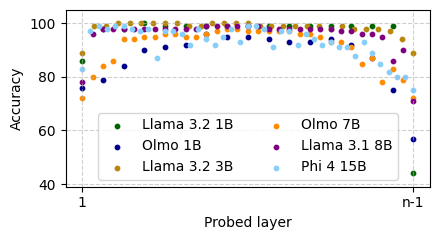

In [64]:
import matplotlib.pyplot as plt
import numpy as np

colors = ["#006400", "#00008B", "#B8860B", "#FF8C00", "#800080", "#87CEFA"]
target_len = max(len(v) for v in data.values())

# --- Plot ---
fig, ax = plt.subplots(figsize=(4.5, 2.5))  # wider canvas

for (label, y), color in zip(data.items(), colors):
    x = np.linspace(0, target_len - 1, len(y))
    ax.scatter(x, y, label=label, color=color, s=10)

# Add margins around points
ax.set_xlim(-2, target_len + 1)
ax.set_ylim(min(min(vals) for vals in data.values()) - 5,
            max(max(vals) for vals in data.values()) + 5)

ax.set_title("")
ax.set_xlabel("Probed layer")
ax.set_ylabel("Accuracy")
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(loc="lower center", ncol=2)
# ax.set_xticks([0])
ax.set_xticks([0, target_len - 1])
ax.set_xticklabels(["1", "n-1"])


fig.tight_layout()
plt.savefig("per_layer_input_accs.pdf", format="pdf")

plt.show()

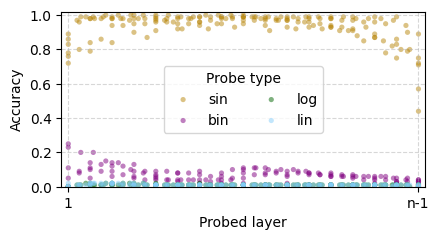

In [82]:
import matplotlib.pyplot as plt
import numpy as np

# parsed using ChatGPT from results of model_activations_probing_no_natural.sh
# ----------------------------
# Raw % accuracies per PROBE TYPE for each model (including SIN)
# ----------------------------
m_llama32_1b = {
    "sin": [86,98,98,100,99,99,99,99,99,99,99,99,99,99,99,99,44],
    "bin": [25,14,14,13,6,3,2,2,2,1,2,1,1,1,2,2,2],
    "lin": [0,2,2,2,1,1,1,1,1,1,1,1,1,1,1,1,0],
    "log": [0,1,2,2,2,1,2,1,1,1,1,1,1,1,1,1,0],
}

m_olmo_0425_1b = {
    "sin": [76,79,84,90,91,92,96,95,95,94,93,93,94,92,87,75,57],
    "bin": [5,5,6,6,7,8,9,8,8,7,6,7,6,6,5,3,3],
    "lin": [0,1,2,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
    "log": [0,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
}

m_llama3b = {
    "sin": [89,99,99,100,100,100,100,100,100,99,99,100,100,100,100,99,99,99,99,99,99,98,99,98,98,98,97,94,89],
    "bin": [23,20,20,15,14,10,8,5,4,4,4,4,4,4,10,11,10,10,10,9,8,8,6,6,6,6,5,4,4],
    "lin": [0,1,2,2,2,2,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    "log": [0,1,1,2,1,1,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
}

m_olmo_1124_7b = {
    "sin": [72,80,84,86,94,94,95,95,96,96,95,95,96,97,98,98,97,97,97,97,97,96,96,95,93,93,91,85,87,78,83,79,72],
    "bin": [11,8,11,13,12,12,9,9,9,9,8,8,7,6,6,5,5,7,8,8,7,8,8,7,6,6,5,4,4,4,3,3,3],
    "lin": [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    "log": [0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
}

m_llama31_8b = {
    "sin": [78,96,98,98,98,98,98,98,98,98,98,98,99,99,99,99,99,99,98,98,98,98,98,98,98,97,97,96,96,95,86,90,71],
    "bin": [0,9,10,9,9,7,5,4,4,4,4,4,4,3,4,10,11,11,11,9,9,9,8,7,7,7,7,6,6,6,5,5,4],
    "lin": [0,1,2,2,2,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    "log": [0,1,1,1,1,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
}

m_phi = {
    "sin": [83,97,99,98,99,99,98,97,98,87,97,97,96,92,98,94,92,95,98,93,99,99,98,91,97,97,92,96,94,92,93,91,91,88,93,89,85,82,80,80,75],
    "bin": [],  # no data in prompt
    "lin": [2,1,1,2,1,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,0],
    "log": [0,1,2,1,1,2,1,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0],
}

models = [m_llama32_1b, m_olmo_0425_1b, m_llama3b, m_olmo_1124_7b, m_llama31_8b, m_phi]

# ----------------------------
# Create unified point list: (x_layer_norm, y_acc, probe_type)
# x = normalized layer position [0,1], y = accuracy [0,1]
# ----------------------------
def make_points(model_dict):
    pts = []
    for probe_type, vals in model_dict.items():
        if len(vals) == 0:
            continue
        arr = np.asarray(vals, dtype=float) / 100.0
        x_layer = np.linspace(0, 1, len(arr))   # normalized position across that model's layers
        y_acc = arr
        pts.extend((float(x), float(y), probe_type) for x, y in zip(x_layer, y_acc))
    return pts

points = []
for md in models:
    points += make_points(md)

# ----------------------------
# Plot: x = normalized layer position, y = accuracy
# Color by probe type (now includes 'sin')
# ----------------------------
fig, ax = plt.subplots(figsize=(4.5, 2.5))

# probe_colors = {
#     "sin": "#FFA500",   # orange
#     "bin": "#1f77b4",   # blue
#     "log": "#d62728",   # red
#     "lin": "#2ca02c",   # green
# }
probe_colors = ["#B8860B", "#800080", "#006400", "#87CEFA" #, "#800080", "#87CEFA"
               ]


for color, ptype in zip(probe_colors, ["sin", "bin", "log", "lin"]):
    xs = [x for (x, y, p) in points if p == ptype]
    ys = [y for (x, y, p) in points if p == ptype]
    if xs:
        ax.scatter(xs, ys, s=14, alpha=0.5, c=color, label=ptype, edgecolors="none")

ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0.0, 1.02)
ax.set_xlabel("Probed layer")
ax.set_ylabel("Accuracy")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(title="Probe type", ncol=2, loc="center")
ax.set_xticks([0, 1])
ax.set_xticklabels(["1", "n-1"])

plt.tight_layout()
plt.savefig("per_layer_per_probe_accs.pdf", format="pdf")

plt.show()